# Using simple Neural Net as an interpolator.
Big idea is to use regression for interpolation instead of the traditional interpolators like pchip and spline.
Tech goal is to learn how to use keras and all.

Codes taken from 
https://carterrhea93.medium.com/using-machine-learning-to-interpolate-values-aac85d60eea5

Pueh Leng Tan, 22 Jan 2025 (think it's 2025 not 2024..)

In [66]:
from keras.models import Sequential
from keras.layers import Dense
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import sklearn.model_selection as skm # just for splitting points up into training and test set

import scipy.interpolate as spi

from datetime import datetime

Text(0.5, 1.0, 'Randomly Sampled Sine Function')

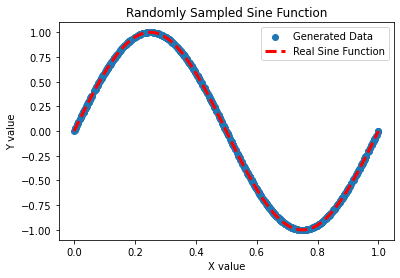

In [19]:
# Define 1D function we want to learn
def function1d(x):
    return np.sin(2*np.pi*x)

# Create sample
x = np.random.random_sample(1000)
y = function1d(x) + 0*np.random.normal(0, .1, 1000)

# Plot
plt.scatter(x,y, label='Generated Data')
plt.plot(np.linspace(0,1,100), function1d(np.linspace(0,1,100)),
         label='Real Sine Function', color='r', linestyle='--', linewidth=3)
plt.legend()
plt.xlabel('X value')
plt.ylabel('Y value')
plt.title("Randomly Sampled Sine Function")

In [20]:
### Model creation: adding layers and compilation
model = Sequential()
model.add(Dense(100, input_dim=1, activation='relu'))
model.add(Dense(100, activation='relu'))
model.add(Dense(1, activation='linear'))

model.compile(optimizer='adam', loss='mse', metrics=['mse'])

Text(0.5, 1.0, 'Randomly Sampled Sine Function')

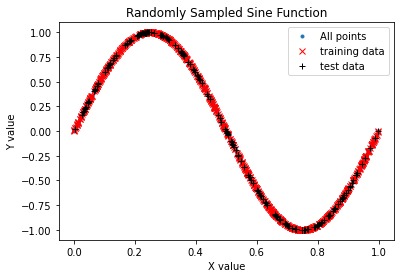

In [21]:
X_train, X_test, y_train, y_test = skm.train_test_split(x, y, test_size=0.2)
plt.plot(x,y, '.', label='All points')
plt.plot(X_train, y_train, 'rx', label='training data')
plt.plot(X_test, y_test, 'k+', label='test data')

plt.legend()
plt.xlabel('X value')
plt.ylabel('Y value')
plt.title("Randomly Sampled Sine Function")

Text(0.5, 0, 'y')

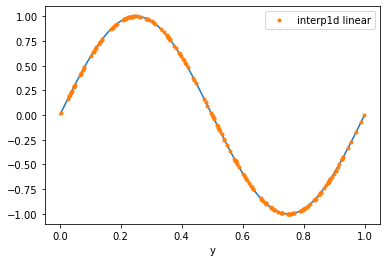

In [22]:
ind = np.argsort(x)
x_sorted = x[ind]
y_sorted = y[ind]

f_interp = spi.interp1d(x_sorted, y_sorted, kind='linear')

plt.plot(x_sorted, y_sorted)
plt.plot(X_test, f_interp(X_test), '.', label='interp1d linear')


plt.legend()
plt.xlabel('x')
plt.xlabel('y')

In [23]:
### Train model
history = model.fit(X_train, y_train, epochs=20, batch_size=4)

Epoch 1/20
200/200 [==============================] - 1s 940us/step - loss: 0.2300 - mse: 0.2300
Epoch 2/20
200/200 [==============================] - 0s 1ms/step - loss: 0.1034 - mse: 0.1034
Epoch 3/20
200/200 [==============================] - 0s 966us/step - loss: 0.0904 - mse: 0.0904
Epoch 4/20
200/200 [==============================] - 0s 1ms/step - loss: 0.0710 - mse: 0.0710
Epoch 5/20
200/200 [==============================] - 0s 888us/step - loss: 0.0564 - mse: 0.0564
Epoch 6/20
200/200 [==============================] - 0s 1ms/step - loss: 0.0456 - mse: 0.0456
Epoch 7/20
200/200 [==============================] - 0s 846us/step - loss: 0.0361 - mse: 0.0361
Epoch 8/20
200/200 [==============================] - 0s 894us/step - loss: 0.0279 - mse: 0.0279
Epoch 9/20
200/200 [==============================] - 0s 896us/step - loss: 0.0217 - mse: 0.0217
Epoch 10/20
200/200 [==============================] - 0s 1ms/step - loss: 0.0176 - mse: 0.0176
Epoch 11/20
200/200 [================

7/7 [==============================] - 0s 1ms/step


Text(0.5, 1.0, 'Randomly Sampled Sine Function')

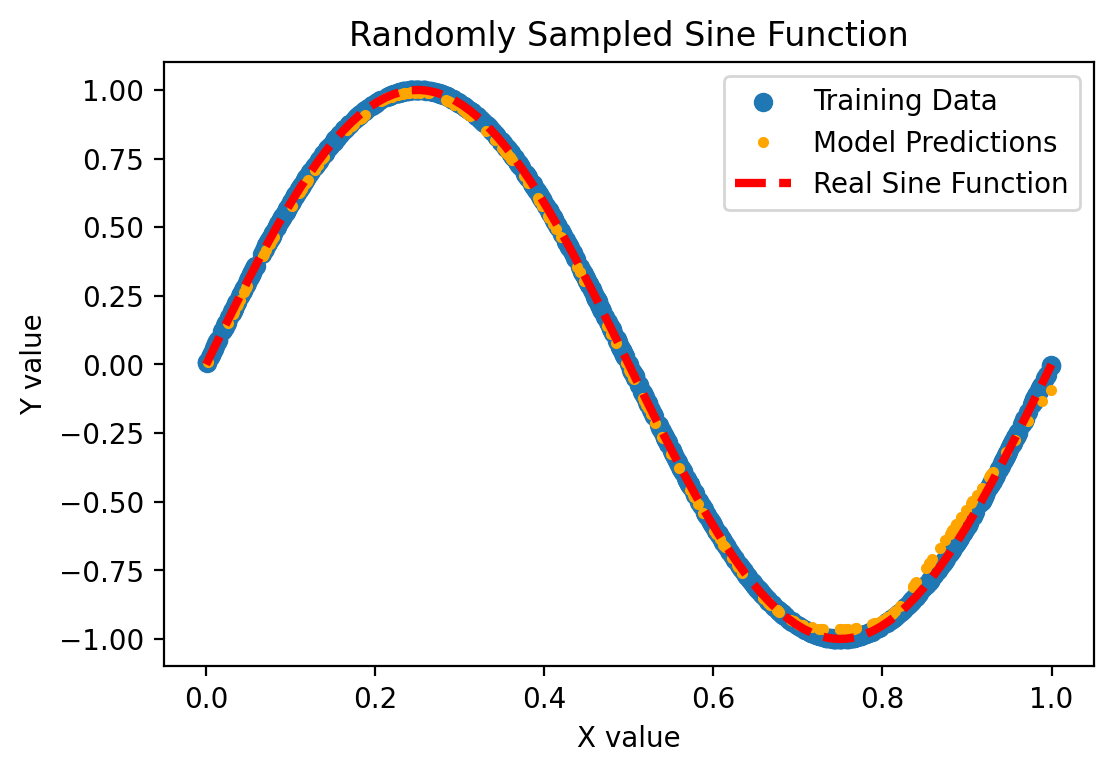

In [24]:
### Prediction
y_pred = model.predict(X_test)

### Visualisation
plt.figure(dpi=200)
plt.scatter(X_train, y_train, label='Training Data')
plt.plot(X_test, y_pred, '.', c='orange', label='Model Predictions')
plt.plot(np.linspace(0,1,100), function1d(np.linspace(0,1,100)), label='Real Sine Function', color='r', linestyle='--', linewidth=3)
plt.legend()
plt.xlabel('X value')
plt.ylabel('Y value')
plt.title("Randomly Sampled Sine Function")

In [25]:
aa = datetime.now()
_dmp = f_interp(X_test)
bb = datetime.now()
bb-aa

datetime.timedelta(microseconds=190)

In [26]:
aa = datetime.now()
_dmp = model.predict(X_test)
bb = datetime.now()
bb-aa

7/7 [==============================] - 0s 1ms/step


datetime.timedelta(microseconds=44658)

ok. so this NN evaluation/prediction is alot slower than evaluating from the spline.

## 2D interpolation

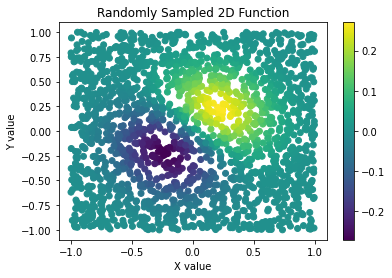

In [27]:
# Define 2D function we want to learn
def function2d(x, y):
    return (x+y)*np.exp(-5.0*(x**2+y**2))

# Create sample
x = 2*np.random.random_sample(2000) - 1
y = 2*np.random.random_sample(2000) - 1
z = function2d(x, y)

# Plot
plt.scatter(x,y, c=z)
plt.xlabel('X value')
plt.ylabel('Y value')
plt.title("Randomly Sampled 2D Function")
plt.colorbar()

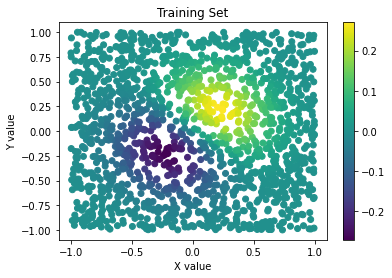

In [29]:
# splitting into training and testing
X_train, X_test, y_train, y_test = skm.train_test_split(np.column_stack((x, y)), z, test_size=0.2)

# Plot
plt.scatter(X_train[:,0], X_train[:,1], c=y_train)
plt.xlabel('X value')
plt.ylabel('Y value')
plt.title("Training Set")
plt.colorbar()

In [30]:
### Model creation: adding layers and compilation
model2D = Sequential()
model2D.add(Dense(100, input_shape=(None, 2), activation='relu'))
model2D.add(Dense(100, activation='relu'))
model2D.add(Dense(1, activation='linear'))

model2D.compile(optimizer='adam', loss='mse', metrics=['mse'])

In [31]:
history = model2D.fit(X_train, y_train, epochs=20, batch_size=4)

Epoch 1/20
400/400 [==============================] - 1s 1ms/step - loss: 0.0023 - mse: 0.0023
Epoch 2/20
400/400 [==============================] - 0s 1ms/step - loss: 6.0059e-04 - mse: 6.0059e-04
Epoch 3/20
400/400 [==============================] - 0s 937us/step - loss: 3.7463e-04 - mse: 3.7463e-04
Epoch 4/20
400/400 [==============================] - 0s 1ms/step - loss: 1.9455e-04 - mse: 1.9455e-04
Epoch 5/20
400/400 [==============================] - 0s 1ms/step - loss: 1.2462e-04 - mse: 1.2462e-04
Epoch 6/20
400/400 [==============================] - 0s 1ms/step - loss: 7.2166e-05 - mse: 7.2166e-05
Epoch 7/20
400/400 [==============================] - 0s 921us/step - loss: 4.6791e-05 - mse: 4.6791e-05
Epoch 8/20
400/400 [==============================] - 0s 906us/step - loss: 4.2224e-05 - mse: 4.2224e-05
Epoch 9/20
400/400 [==============================] - 0s 976us/step - loss: 7.0366e-05 - mse: 7.0366e-05
Epoch 10/20
400/400 [==============================] - 0s 1ms/step - loss

In [32]:
z_pred = model2D.predict(X_test)

13/13 [==============================] - 0s 974us/step


In [63]:
raw_diff = (np.squeeze(z_pred))-y_test
percentage_diff = ((np.squeeze(z_pred))-y_test)*100./y_test

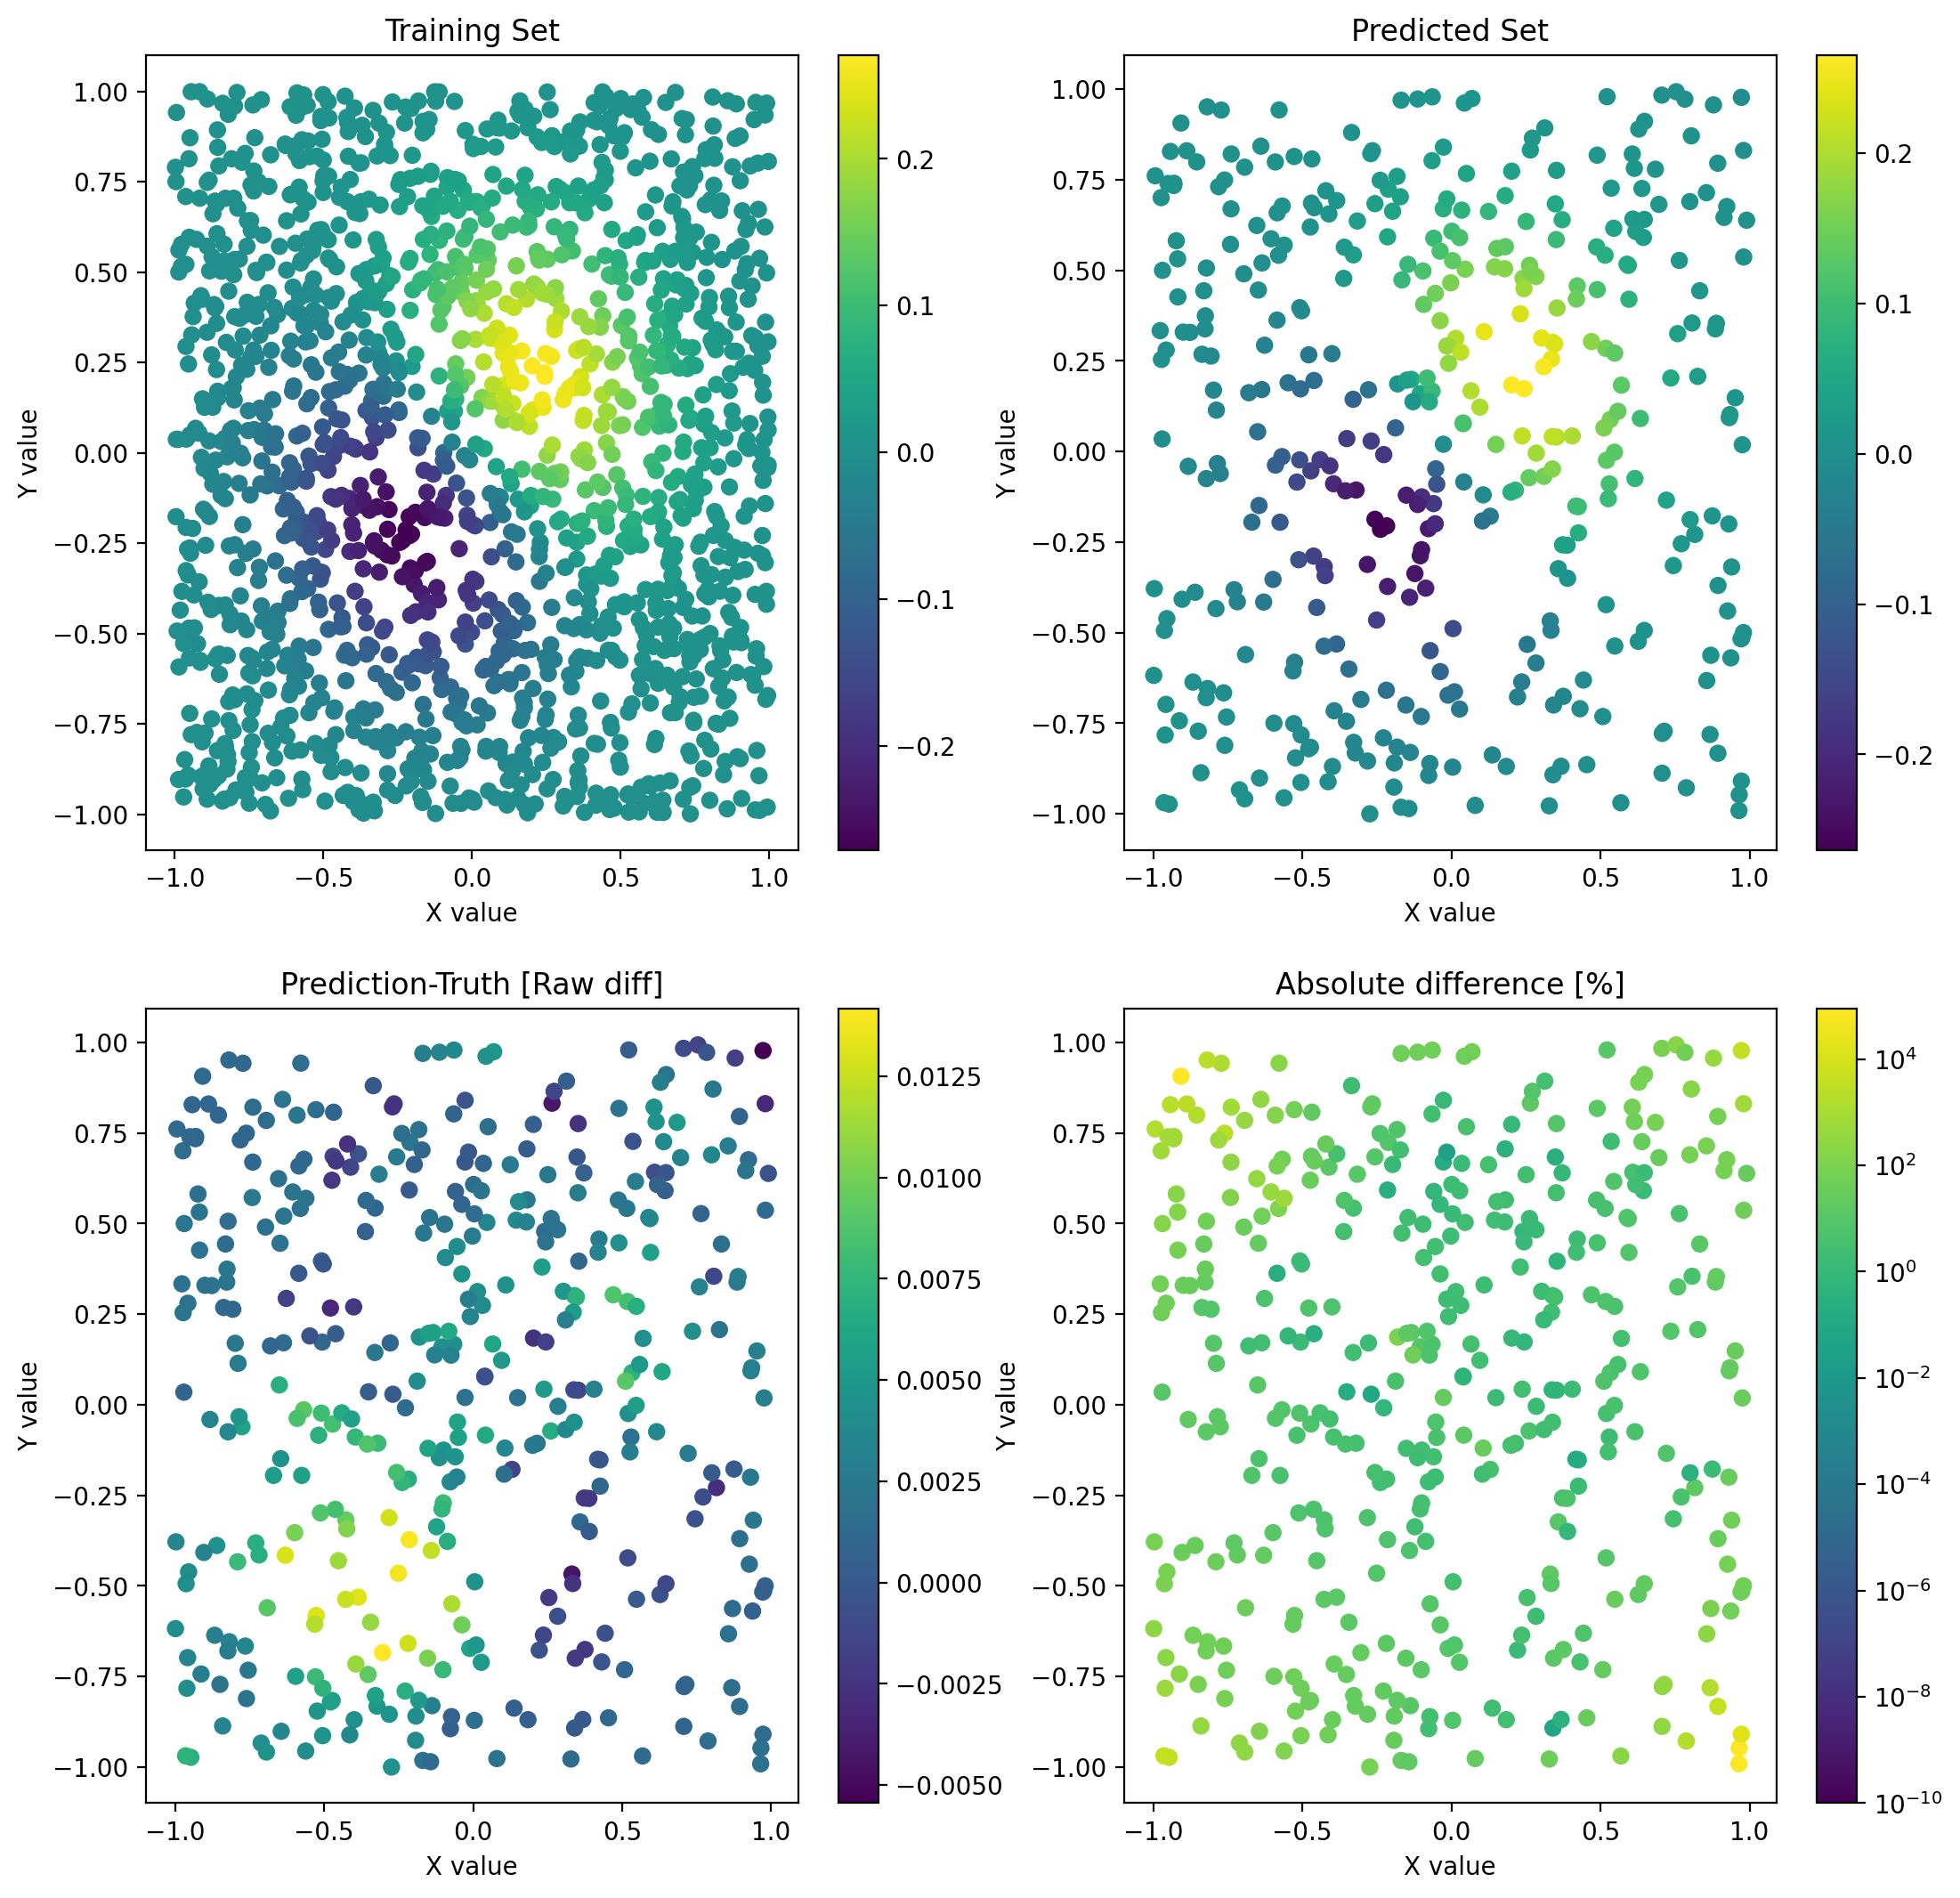

In [79]:
plt.figure(dpi=200, figsize=(13, 13))
plt.subplot(221)
plt.scatter(X_train[:,0], X_train[:,1], c=y_train)
plt.xlabel('X value')
plt.ylabel('Y value')
plt.title("Training Set")
plt.colorbar()

plt.subplot(222)
plt.scatter(X_test[:,0], X_test[:,1], c=z_pred)
plt.xlabel('X value')
plt.ylabel('Y value')
plt.title("Predicted Set")
plt.colorbar()

plt.subplot(223)
plt.scatter(X_test[:,0], X_test[:,1], c=raw_diff)
plt.xlabel('X value')
plt.ylabel('Y value')
plt.title("Prediction-Truth [Raw diff]")
plt.colorbar()

plt.subplot(224)
norm = mcolors.LogNorm(
    vmin=1e-10,
    #vmin=max(1e-10, np.min(percentage_diff[percentage_diff > 0])),
                       vmax=np.max(percentage_diff))
plt.scatter(X_test[:,0], X_test[:,1], c=np.abs(percentage_diff), norm=norm)
plt.xlabel('X value')
plt.ylabel('Y value')
plt.title("Absolute difference [%]")
plt.colorbar()

In [112]:
xx_arr = np.linspace(-2, 2, 50)
yy_arr = np.linspace(-2, 2, 50)

aa, bb = np.meshgrid(xx_arr, yy_arr)
aa = aa.ravel()
bb = bb.ravel()
my_test = np.vstack((aa, bb)).T

In [116]:
cc = model2D.predict(my_test)

79/79 [==============================] - 0s 809us/step


In [132]:
truth = function2d(aa, bb)
raw_diff = np.squeeze(cc)-truth
abs_diff = abs(raw_diff)
percentage_diff = raw_diff*100./truth

/tmp/ipykernel_33190/3211213236.py:4: RuntimeWarning: divide by zero encountered in true_divide
  percentage_diff = raw_diff*100./truth


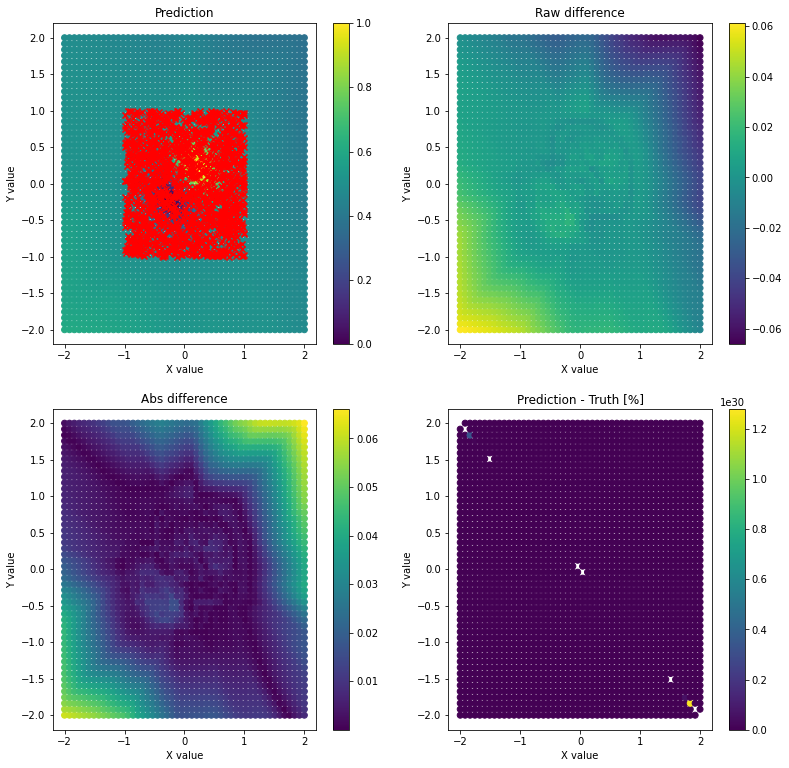

In [138]:
'''
norm = mcolors.LogNorm(
    vmin=1e-10,
    #vmin=max(1e-10, np.min(percentage_diff[percentage_diff > 0])),
                       vmax=np.max(percentage_diff))
#'''
plt.figure(figsize=(13, 13))
plt.subplot(221)
plt.scatter(aa, bb, c=cc)
plt.scatter(X_train[:,0], X_train[:,1], c='r', marker='x', label='Training samples')
plt.xlabel('X value')
plt.ylabel('Y value')
plt.title("Prediction")
plt.colorbar()

plt.subplot(222)
plt.scatter(aa, bb, c=raw_diff)
plt.xlabel('X value')
plt.ylabel('Y value')
plt.title("Raw difference")
plt.colorbar()

plt.subplot(223)
plt.scatter(aa, bb, c=abs_diff)
plt.xlabel('X value')
plt.ylabel('Y value')
plt.title("Abs difference")
plt.colorbar()

plt.subplot(224)
plt.scatter(aa, bb, c=percentage_diff)
plt.xlabel('X value')
plt.ylabel('Y value')
plt.title("Prediction - Truth [%]")
plt.colorbar()

What happens if points are not in a square but in a circle?

In [34]:
raise

((400, 2), (400, 1))

In [35]:
xx, yy = np.meshgrid(
    np.unique(X_test[:, 0]), 
    np.unique(X_test[:, 1])
)
z_grid = z_pred.reshape(xx.shape)  # Ensure z_pred matches the grid shape

plt.subplot(122)
plt.contourf(xx, yy, z_grid, levels=50, cmap='viridis')
plt.colorbar()
plt.xlabel('X value')
plt.ylabel('Y value')
plt.title("Predicted Set")

ValueError: cannot reshape array of size 400 into shape (400,400)

In [ ]:
### Test to see how stochastic things are
model2D2 = Sequential()
model2D2.add(Dense(100, input_shape=(None, 2), activation='relu'))
model2D2.add(Dense(100, activation='relu'))
model2D2.add(Dense(1, activation='linear'))
model2D2.compile(optimizer='adam', loss='mse', metrics=['mse'])

In [ ]:
history2 = model2D2.fit(X_train, y_train, epochs=20, batch_size=4)

In [ ]:
z_pred2 = model2D2.predict(X_test)

In [ ]:
le, ue

In [ ]:
aa = np.concatenate([z_pred, z_pred2])
le, ue = min(aa), max(aa)
num_bins = 50
bin_edges = np.squeeze(np.linspace(le, ue, num_bins))
plt.hist(z_pred, histtype='step', bins=bin_edges)
plt.hist(z_pred2, histtype='step', bins=bin_edges)

And I lazily and unrigourously concluded that two instances of NN with same architecture (but with different initialisation of the weights) but trained on the same data give, without computation of residuals or any two-sample testings, similar prediction by eye.